<a href="https://colab.research.google.com/github/RetroAchiever01/platformes_kai_arxitektonikes_nefous/blob/main/ergasia_platfores_kai_arx_nefous.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import pandas as pd

# Φόρτωση του dataset με την βιβλιοθήκη pandas
df_pandas = pd.read_csv('creditcard.csv')

# Εμφάνιση των πρώτων 5 γραμμών και του μεγέθους
print(f"Το dataset έχει {df_pandas.shape[0]} γραμμές και {df_pandas.shape[1]} στήλες.")
display(df_pandas.head())


Το dataset έχει 284807 γραμμές και 31 στήλες.


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [13]:
from pyspark.sql import SparkSession

# Εκκίνηση του Spark Session
spark = SparkSession.builder \
    .appName("FraudDetection_Project") \
    .master("local[*]") \
    .getOrCreate()

# Φόρτωση του dataset με PySpark
df_spark = spark.read.csv('creditcard.csv', header=True, inferSchema=True)

# Εμφάνιση του σχήματος και των πρώτων 5 γραμμών
print(f"Το dataset έχει {df_spark.count()} γραμμές.")
df_spark.show(5)

Το dataset έχει 284807 γραμμές.
+----+------------------+-------------------+----------------+------------------+-------------------+-------------------+-------------------+------------------+------------------+-------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------+-------------------+--------------------+-------------------+------------------+------------------+------------------+------------------+--------------------+-------------------+------+-----+
|Time|                V1|                 V2|              V3|                V4|                 V5|                 V6|                 V7|                V8|                V9|                V10|               V11|               V12|               V13|               V14|               V15|               V16|               V17|                V18|               V19|                V20|              

In [23]:
import time
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

#Διαγράφουμε τις γραμμές που έχουν κενές τιμές
df_pandas = df_pandas.dropna()

# 1. Χωρίζουμε τα δεδομένα σε Features (X) και Target (X)
X = df_pandas.drop('Class', axis=1)
y = df_pandas['Class']

# 2. Χωρίζουμε σε σύνολα εκπαίδευσης (Train - 80%) και δοκιμής (Test - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ξεκινάει η εκπαίδευση με Scikit-learn...")
start_time_sklearn = time.time()  # Ξεκινάμε το χρονόμετρο

# 3. Ορίζουμε και εκπαιδεύουμε το μοντέλο
rf_sklearn = RandomForestClassifier(n_estimators=20, random_state=42)
rf_sklearn.fit(X_train, y_train)

# 4. Κάνουμε προβλέψεις και υπολογίζουμε την ακρίβεια
predictions_sklearn = rf_sklearn.predict(X_test)
accuracy_sklearn = accuracy_score(y_test, predictions_sklearn)

end_time_sklearn = time.time()  # Σταματάμε το χρονόμετρο
time_sklearn = end_time_sklearn - start_time_sklearn

print("-" * 30)

print(f"Scikit-learn Χρόνος Εκτέλεσης: {time_sklearn:.2f} δευτερόλεπτα")
print(f"Scikit-learn Ακρίβεια (Accuracy): {accuracy_sklearn * 100:.2f}%")

Ξεκινάει η εκπαίδευση με Scikit-learn...
------------------------------
Scikit-learn Χρόνος Εκτέλεσης: 83.87 δευτερόλεπτα
Scikit-learn Ακρίβεια (Accuracy): 99.95%


In [24]:
import time
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier as SparkRF
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print("Προετοιμασία δεδομένων για το PySpark...")
feature_columns = [col for col in df_spark.columns if col != 'Class']
assembler = VectorAssembler(inputCols=feature_columns, outputCol="features")
df_spark_prepared = assembler.transform(df_spark)

# Χωρίζουμε σε Train (80%) και Test (20%)
train_data, test_data = df_spark_prepared.randomSplit([0.8, 0.2], seed=42)

print("Ξεκινάει η εκπαίδευση με PySpark... ")
start_time_spark = time.time()  # Ξεκινάμε το χρονόμετρο

# Ορίζουμε και εκπαιδεύουμε το μοντέλο (ίδιες ρυθμίσεις: 20 δέντρα)
rf_spark = SparkRF(featuresCol="features", labelCol="Class", numTrees=20, seed=42)
model_spark = rf_spark.fit(train_data)

# Κάνουμε προβλέψεις
predictions_spark = model_spark.transform(test_data)

# Υπολογίζουμε την ακρίβεια
evaluator = MulticlassClassificationEvaluator(labelCol="Class", predictionCol="prediction", metricName="accuracy")
accuracy_spark = evaluator.evaluate(predictions_spark)

end_time_spark = time.time()  # Σταματάμε το χρονόμετρο
time_spark = end_time_spark - start_time_spark

print("-" * 30)
print(f"PySpark Χρόνος Εκτέλεσης: {time_spark:.2f} δευτερόλεπτα")
print(f"PySpark Ακρίβεια (Accuracy): {accuracy_spark * 100:.2f}%")

Προετοιμασία δεδομένων για το PySpark...
Ξεκινάει η εκπαίδευση με PySpark... 
------------------------------
PySpark Χρόνος Εκτέλεσης: 34.15 δευτερόλεπτα
PySpark Ακρίβεια (Accuracy): 99.94%


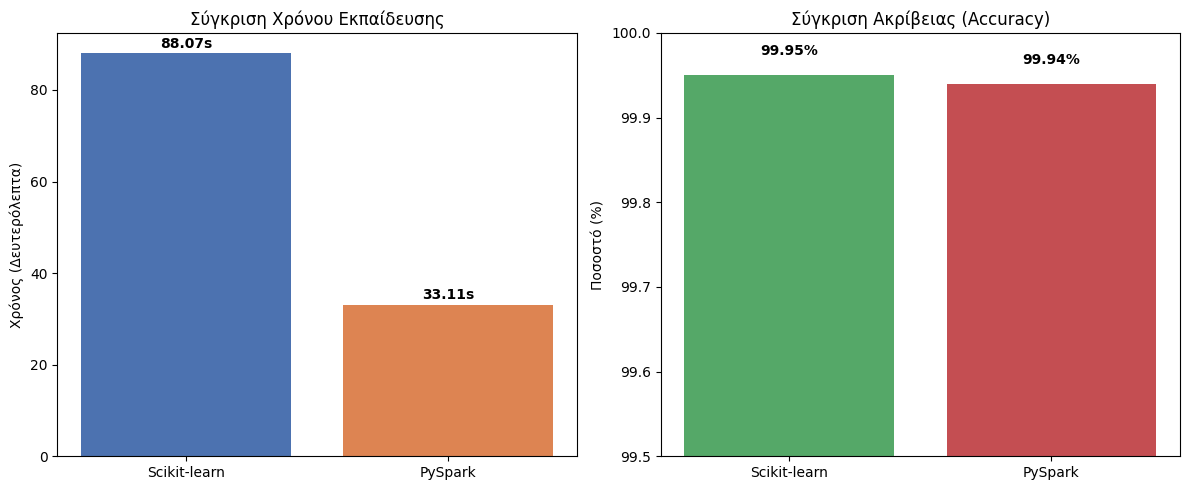

In [22]:
import matplotlib.pyplot as plt

# Τα αποτελέσματα
methods = ['Scikit-learn', 'PySpark']
times = [88.07 , 33.11]
accuracies = [99.95, 99.94]

# Δημιουργία σχήματος με 2 γραφήματα δίπλα-δίπλα
plt.figure(figsize=(12, 5))

# Γράφημα 1: Χρόνος Εκτέλεσης (Όσο πιο χαμηλά, τόσο καλύτερα)
plt.subplot(1, 2, 1)
bars1 = plt.bar(methods, times, color=['#4C72B0', '#DD8452'])
plt.title('Σύγκριση Χρόνου Εκπαίδευσης')
plt.ylabel('Χρόνος (Δευτερόλεπτα)')

# Προσθήκη των αριθμών πάνω από κάθε μπάρα
for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f"{yval}s", ha='center', va='bottom', fontweight='bold')

# Γράφημα 2: Ακρίβεια (Accuracy)
plt.subplot(1, 2, 2)
bars2 = plt.bar(methods, accuracies, color=['#55A868', '#C44E52'])
plt.title('Σύγκριση Ακρίβειας (Accuracy)')
plt.ylabel('Ποσοστό (%)')
# Ρυθμίζουμε τον άξονα Y να ξεκινάει από το 99 για να φανεί έστω και η ελάχιστη διαφορά
plt.ylim(99.5, 100)

# Προσθήκη των αριθμών πάνω από κάθε μπάρα
for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval}%", ha='center', va='bottom', fontweight='bold')

# Εμφάνιση των γραφημάτων
plt.tight_layout()
plt.show()